# True Convergence Tests

In this document, I am running through paper ready plots for all of the hierarchy convergence tests. In this case, we first focus on convergence by comparing specfically to our base models in each case. Following this, we all our models to vary the last parameter and apply a shift to test convergence.

Initial imports for this:

In [1]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



## Define the Base Model: Higgs Inflation

If you would like to, you can expand this to include 5-9 safely.

In [61]:
LAM_BASE = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
    9: ("lam6", 6.1e-10),
}



If I want to pull base files with my naming scheme I use the function below:

In [62]:

def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder


We can upload them like so:

In [63]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

NEQS=6: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6/lam3_-4.6097100000e-06
NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_6.8706500000e-08
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-8.9246100000e-09
NEQS=9: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs9/lam6_6.1000000000e-10


When I run my code I modified it to also include the original N information which I can include. If I want to print that information out I can do that as well:

In [64]:
def load_base_summary_row(NEQS, param_name, base_value, base_path_root):
    summary_file = f"{base_path_root}/neqs{NEQS}/neqs{NEQS}_summary.csv"
    df = pd.read_csv(summary_file)

    idx = np.argmin(np.abs(df[param_name] - base_value))
    return df.iloc[idx]

rows = []

for NEQS, (param_name, base_val) in LAM_BASE.items():
    row = load_base_summary_row(NEQS, param_name, base_val, base_path_root)

    rows.append({
        "NEQS": NEQS,
        "param": param_name,
        "value": row[param_name],
        "n_s": row["n_s"],
        "r": row["r"],
        "original_N_end": row["original_N_end"],
        "spectrum_N_start": row["spectrum_N_start"],
        "path_N_end": row["path_N_end"],
    })

base_summary_df = pd.DataFrame(rows)
print(base_summary_df.to_string(index=False))

#Compare relative to 6 base
ref = base_summary_df.loc[base_summary_df["NEQS"] == 6, "original_N_end"].iloc[0]

base_summary_df["delta_N_vs_NEQS6"] = (
    base_summary_df["original_N_end"] - ref
)


#This will print the information
print(base_summary_df.to_string(index=False))

 NEQS param         value      n_s        r  original_N_end  spectrum_N_start  path_N_end
    6  lam3 -4.609710e-06 0.965678 0.003454      939.163572          0.000160        60.0
    7  lam4  6.870650e-08 0.967201 0.003158      941.837071          0.000156        60.0
    8  lam5 -8.924610e-09 0.969485 0.002737      946.349733          0.000156        60.0
    9  lam6  6.100000e-10 0.970677 0.002529      948.989450          0.000156        60.0
 NEQS param         value      n_s        r  original_N_end  spectrum_N_start  path_N_end  delta_N_vs_NEQS6
    6  lam3 -4.609710e-06 0.965678 0.003454      939.163572          0.000160        60.0          0.000000
    7  lam4  6.870650e-08 0.967201 0.003158      941.837071          0.000156        60.0          2.673499
    8  lam5 -8.924610e-09 0.969485 0.002737      946.349733          0.000156        60.0          7.186161
    9  lam6  6.100000e-10 0.970677 0.002529      948.989450          0.000156        60.0          9.825878


## Re-Used Functions

We have the set of functions that tend to get re-used here:

In [87]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "mediumseagreen",
    6: "lightskyblue",
    7: "paleturquoise",
    8: "thistle",
    9: "pink",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac



## BEFORE SHIFTING

First, is the Hubble parameter and the potential as function of e-folds. We only limit this for now to look from 60 down to 20 e-folds. No shifting has occured.

In [88]:
def plot_HV_shape_only_with_frac_error_limitedN(
    base_path_root,
    save_name=None,
    suptitle=None,
    N_ref=60.0,
    ref_floor=1e-20,
    frac_floor=1e-30,
    N_min=20.0,
    N_max=60.0,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    base_models = {
        6: ("lam3", -4.60971e-6),
        7: ("lam4",  6.87065e-8),
        8: ("lam5", -8.92461e-9),
        9: ("lam6", 6.1e-10),
    }

    def apply_N_window(N, Y):
        mask = (N >= N_min) & (N <= N_max)
        return N[mask], Y[mask]

    model_data = {}

    for NEQS, (param_name, base_value) in base_models.items():
        data = load_path_data(NEQS, param_name, base_value)

        N = data[:, NEQS]
        H = data[:, 1]
        V = data[:, NEQS + 1]

        N_H, H_norm, Hstar = normalize_curve_at_Nref(
            N,
            H,
            N_ref=N_ref,
            ref_floor=ref_floor,
        )

        N_V, V_norm, Vstar = normalize_curve_at_Nref(
            N,
            V,
            N_ref=N_ref,
            ref_floor=ref_floor,
        )

        N_H, H_norm = apply_N_window(N_H, H_norm)
        N_V, V_norm = apply_N_window(N_V, V_norm)

        model_data[NEQS] = {
            "N_H": N_H,
            "H_norm": H_norm,
            "H_ref": Hstar,

            "N_V": N_V,
            "V_norm": V_norm,
            "V_ref": Vstar,

            "param_name": param_name,
            "base_value": base_value,
        }

    ref_curve = model_data[6]

    fig, axs = plt.subplots(
        2,
        2,
        figsize=(18, 10),
        constrained_layout=True,
    )

    ax_H, ax_V = axs[0]
    ax_dH, ax_dV = axs[1]

    # -------------------------------------------------
    # Top row: normalized H and V
    # -------------------------------------------------
    for NEQS, d in model_data.items():
        label = rf"NEQS={NEQS}, ${d['param_name']}={d['base_value']:.2e}$"

        ax_H.plot(
            d["N_H"],
            d["H_norm"],
            lw=2.4,
            color=colors[NEQS],
            label=label,
        )

        ax_V.plot(
            d["N_V"],
            d["V_norm"],
            lw=2.4,
            color=colors[NEQS],
            label=label,
        )

    ax_H.set_title(rf"Shape-only Hubble evolution: $H/H(N={N_ref})$")
    ax_V.set_title(rf"Shape-only potential evolution: $V/V(N={N_ref})$")

    ax_H.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_V.set_ylabel(rf"$V/V(N={N_ref})$")

    # -------------------------------------------------
    # Bottom row: fractional differences vs NEQS=6
    # -------------------------------------------------
    for NEQS, d in model_data.items():
        N_use_H, frac_H = fractional_difference_on_overlap(
            d["N_H"],
            d["H_norm"],
            ref_curve["N_H"],
            ref_curve["H_norm"],
            frac_floor=frac_floor,
        )

        N_use_V, frac_V = fractional_difference_on_overlap(
            d["N_V"],
            d["V_norm"],
            ref_curve["N_V"],
            ref_curve["V_norm"],
            frac_floor=frac_floor,
        )

        ax_dH.plot(
            N_use_H,
            100.0 * frac_H,
            lw=2.2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}",
        )

        ax_dV.plot(
            N_use_V,
            100.0 * frac_V,
            lw=2.2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}",
        )

    ax_dH.axhline(0.0, color="black", linestyle="--", lw=1.1, alpha=0.65)
    ax_dV.axhline(0.0, color="black", linestyle="--", lw=1.1, alpha=0.65)

    ax_dH.set_title(r"Fractional difference in $H(N)$ relative to NEQS=6")
    ax_dV.set_title(r"Fractional difference in $V(N)$ relative to NEQS=6")

    ax_dH.set_xlabel(r"$N$")
    ax_dV.set_xlabel(r"$N$")

    ax_dH.set_ylabel(r"$100\times\Delta H/H_{\rm NEQS=6}$")
    ax_dV.set_ylabel(r"$100\times\Delta V/V_{\rm NEQS=6}$")

    # -------------------------------------------------
    # Styling
    # -------------------------------------------------
    for ax in axs.ravel():
        ax.invert_xaxis()
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(frameon=False, fontsize=11)

    if suptitle is None:
        suptitle = rf"Base-model background convergence over ${N_min}<N<{N_max}$"

    fig.suptitle(suptitle, fontsize=22)

    if save_name is None:
        save_name = "HV_shape_only_windowed_with_frac_errors.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

We can run this like so:

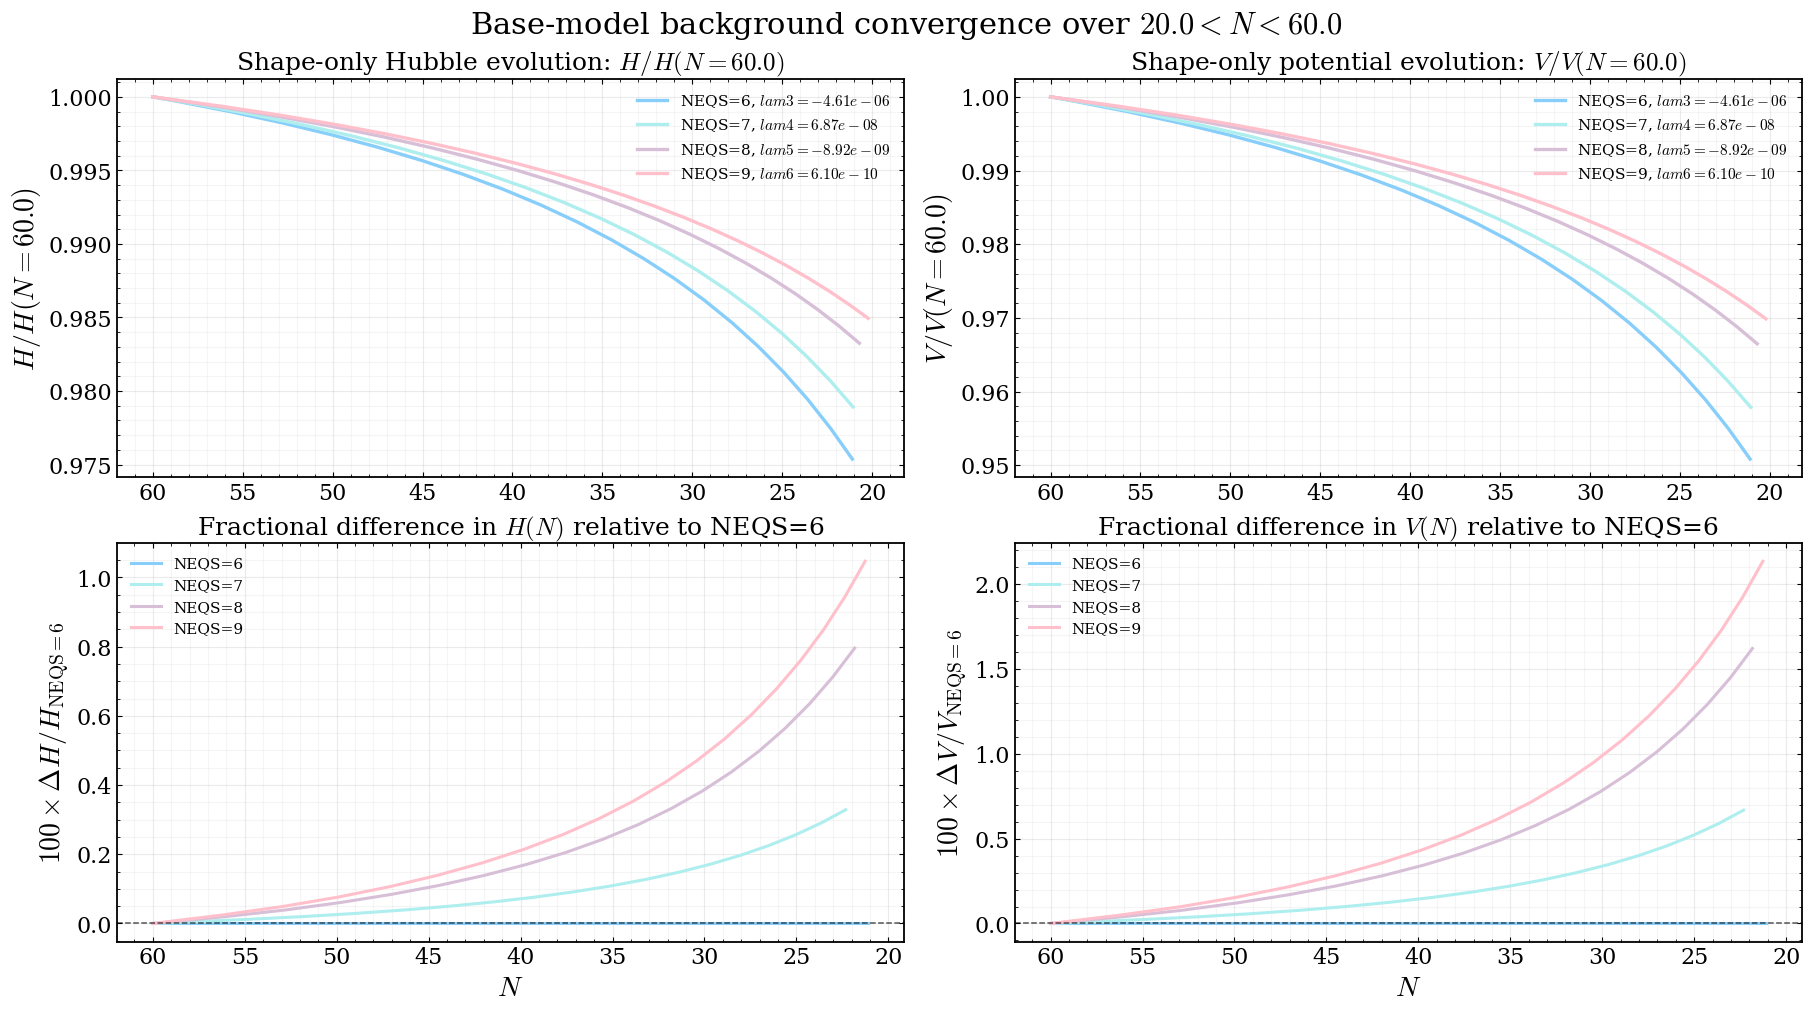

In [90]:
plot_HV_shape_only_with_frac_error_limitedN(
    base_path_root=base_path_root,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
    save_name="HV_shape_only_windowed_with_frac_errors.png",
    
)



Let's check out our spectra now:

In [91]:
def plot_base_spectra_overlay_with_frac_errors(
    base_path_root,
    base_params=None,
    ref_NEQS=6,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    normalize=True,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
            9: ("lam6", 6.1e-10),
        }

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref, P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref, k_cmp, P_cmp, kmin=None, kmax=None):
        k_ref_grid, P_ref = prepare_increasing(k_ref_grid, P_ref)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

        k_use = k_ref_grid[mask]
        P_ref_use = P_ref[mask]

        if len(k_use) == 0:
            raise ValueError("No overlapping k range for fractional error.")

        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    # Load reference model
    ref_param, ref_value = base_params[ref_NEQS]

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    if normalize:
        k_s_ref, Ps_ref, _ = normalize_at_ref(k_s_ref_raw, Ps_ref_raw)
        k_t_ref, Pt_ref, _ = normalize_at_ref(k_t_ref_raw, Pt_ref_raw)
        ylab_s = rf"$P_s/P_s(k={k_ref})$"
        ylab_t = rf"$P_t/P_t(k={k_ref})$"
    else:
        k_s_ref, Ps_ref = prepare_increasing(k_s_ref_raw, Ps_ref_raw)
        k_t_ref, Pt_ref = prepare_increasing(k_t_ref_raw, Pt_ref_raw)
        ylab_s = r"$P_s(k)$"
        ylab_t = r"$P_t(k)$"

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_s, ax_t = axes[0]
    ax_s_err, ax_t_err = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
            NEQS,
            param_name,
            value,
        )

        if normalize:
            k_s, Ps_plot, _ = normalize_at_ref(k_s_raw, Ps_raw)
            k_t, Pt_plot, _ = normalize_at_ref(k_t_raw, Pt_raw)
        else:
            k_s, Ps_plot = prepare_increasing(k_s_raw, Ps_raw)
            k_t, Pt_plot = prepare_increasing(k_t_raw, Pt_raw)

        color = colors.get(NEQS, None)
        label = rf"NEQS={NEQS}, ${param_name}={value:.2e}$"

        scalar_mask = np.ones_like(k_s, dtype=bool)

        if k_min_scalar is not None:
            scalar_mask &= k_s >= k_min_scalar

        if k_max_scalar is not None:
            scalar_mask &= k_s <= k_max_scalar

        ax_s.loglog(
            k_s[scalar_mask],
            Ps_plot[scalar_mask],
            color=color,
            lw=2.3,
            label=label,
        )

        ax_t.loglog(
            k_t,
            Pt_plot,
            color=color,
            lw=2.3,
            label=label,
        )

        k_s_err, frac_s = frac_on_ref_grid(
            k_s_ref,
            Ps_ref,
            k_s,
            Ps_plot,
            kmin=k_min_scalar,
            kmax=k_max_scalar,
        )

        k_t_err, frac_t = frac_on_ref_grid(
            k_t_ref,
            Pt_ref,
            k_t,
            Pt_plot,
            kmin=None,
            kmax=None,
        )

        ax_s_err.semilogx(
            k_s_err,
            100.0 * frac_s,
            color=color,
            lw=2.0,
            label=rf"NEQS={NEQS}",
        )

        ax_t_err.semilogx(
            k_t_err,
            100.0 * frac_t,
            color=color,
            lw=2.0,
            label=rf"NEQS={NEQS}",
        )

        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,
            "value": value,
            "mean_abs_dPs_pct": 100.0 * np.nanmean(np.abs(frac_s)),
            "max_abs_dPs_pct": 100.0 * np.nanmax(np.abs(frac_s)),
            "mean_abs_dPt_pct": 100.0 * np.nanmean(np.abs(frac_t)),
            "max_abs_dPt_pct": 100.0 * np.nanmax(np.abs(frac_t)),
        })

    # Reference lines
    ax_s.axvline(k_ref, color="black", ls=":", lw=1.2, alpha=0.7)
    ax_t.axvline(k_ref, color="black", ls=":", lw=1.2, alpha=0.7)

    for ax in [ax_s_err, ax_t_err]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)
        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.8,
            label=rf"${tolerance:.0f}\%$ tolerance",
        )
        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.8,
        )

    ax_s.set_title(r"Base scalar spectra")
    ax_t.set_title(r"Base tensor spectra")
    ax_s_err.set_title(rf"Scalar fractional difference relative to NEQS={ref_NEQS}")
    ax_t_err.set_title(rf"Tensor fractional difference relative to NEQS={ref_NEQS}")

    ax_s.set_xlabel(r"$k$")
    ax_t.set_xlabel(r"$k$")
    ax_s_err.set_xlabel(r"$k$")
    ax_t_err.set_xlabel(r"$k$")

    ax_s.set_ylabel(ylab_s)
    ax_t.set_ylabel(ylab_t)
    ax_s_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm NEQS=6}$")
    ax_t_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm NEQS=6}$")

    ax_s.set_xlim(k_min_scalar, k_max_scalar)
    ax_s_err.set_xlim(k_min_scalar, k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()
        ax.legend(frameon=False, fontsize=11)

    fig.suptitle(
        rf"Base-model spectra convergence relative to NEQS={ref_NEQS}",
        fontsize=22,
    )

    if save_name is None:
        save_name = "base_spectra_convergence_with_fractional_errors.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Base spectra convergence summary ===")
    print(summary_df.to_string(index=False))

    return summary_df

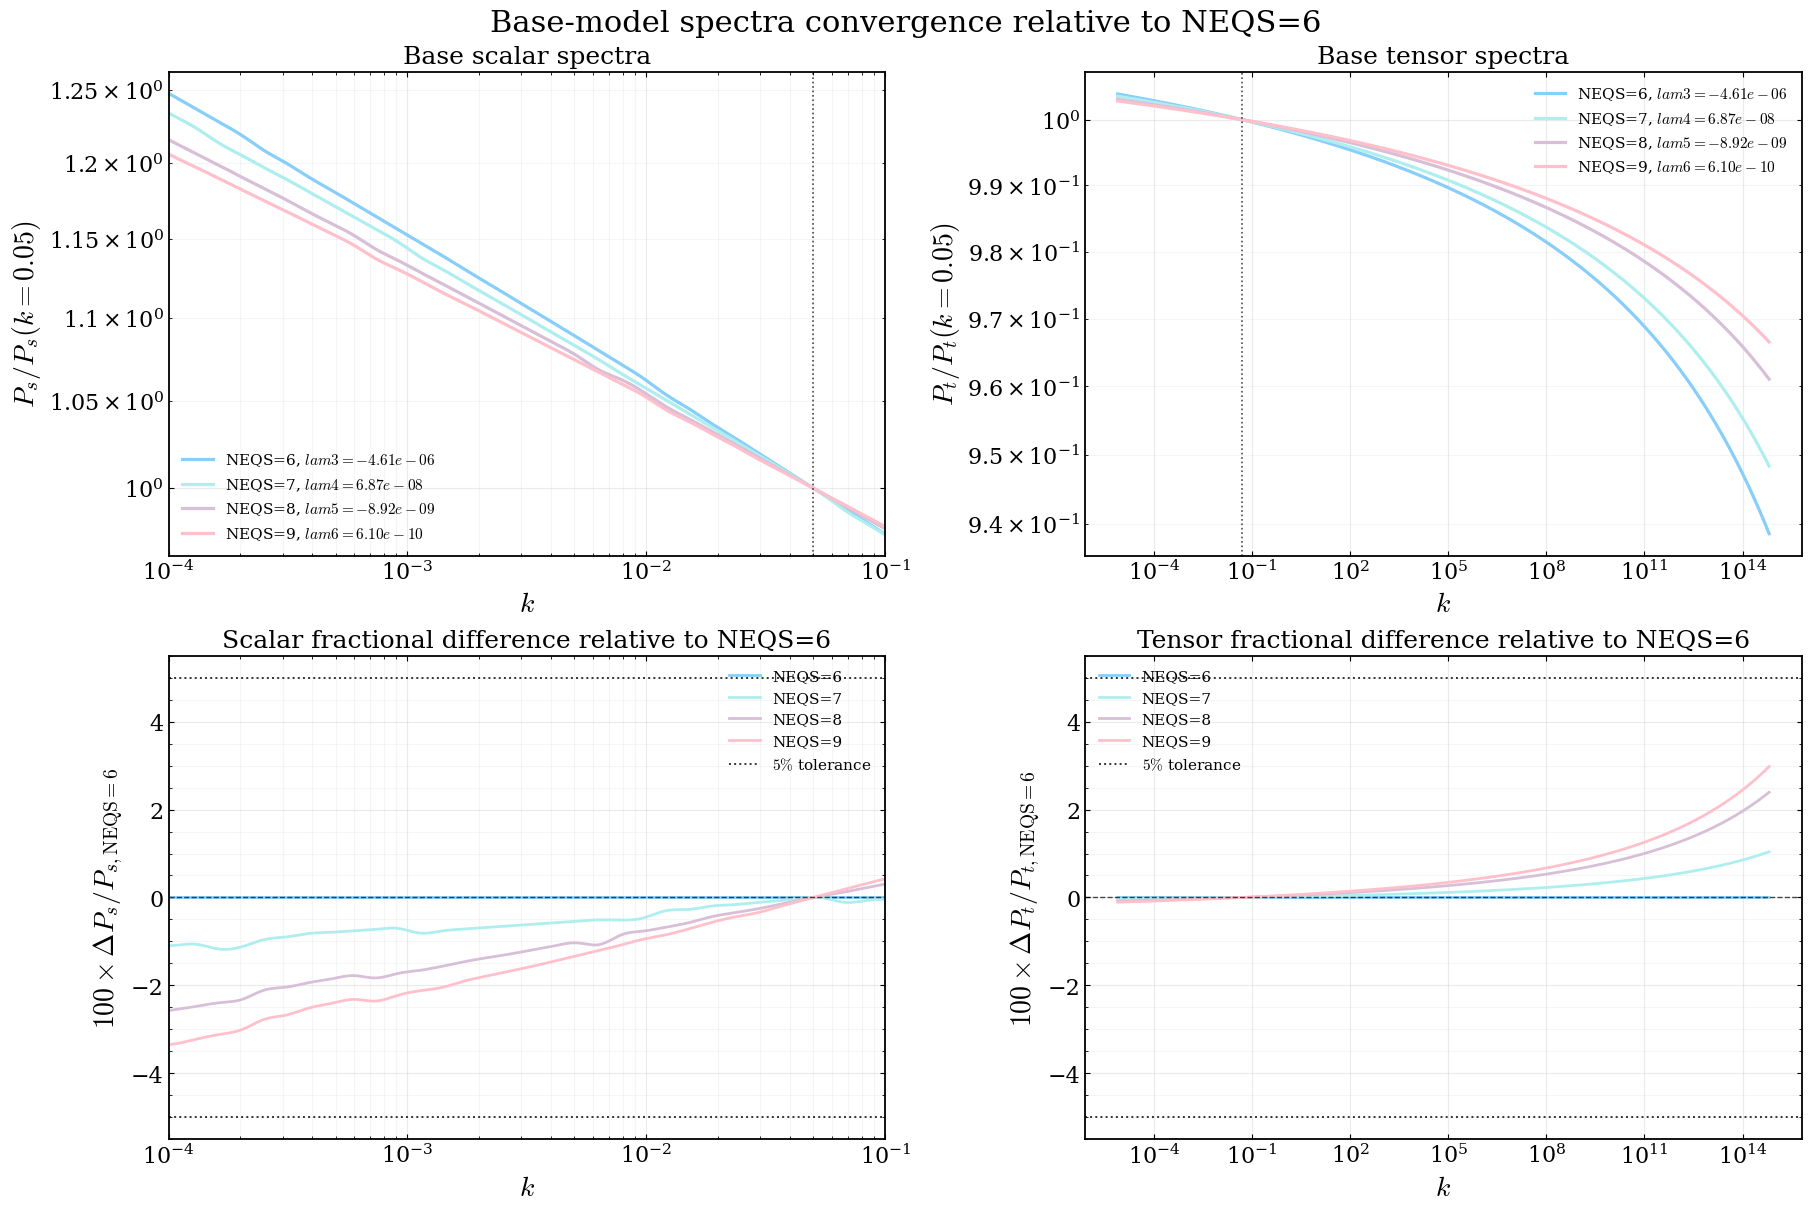


=== Base spectra convergence summary ===
 NEQS param_name         value  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    6       lam3 -4.609710e-06          0.000000         0.000000          0.000000         0.000000
    7       lam4  6.870650e-08          0.563139         1.181432          0.223213         1.039358
    8       lam5 -8.924610e-09          1.210051         2.567313          0.517595         2.394061
    9       lam6  6.100000e-10          1.566446         3.346599          0.649888         2.978353


In [92]:
base_spectra_summary_df = plot_base_spectra_overlay_with_frac_errors(
    base_path_root=base_path_root,
    base_params={
        6: ("lam3", -4.60971e-6),
        7: ("lam4",  6.87065e-8),
        8: ("lam5", -8.92461e-9),
        9: ("lam6", 6.1e-10),
    },
    ref_NEQS=6,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=5.0,
    save_name="base_spectra_convergence_relative_to_neqs6_preshift.png",
)

We can also examine the shape of the spectra:

In [111]:
def plot_base_spectra_derivative_convergence(
    base_path_root,
    base_params=None,
    ref_NEQS=6,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
            9: ("lam6", 6.1e-10),
        }

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs_local(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (
            (k > 0)
            & (P > 0)
            & np.isfinite(k)
            & np.isfinite(P)
        )

        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        x_unique = np.unique(x)
        y_unique = np.array([np.mean(y[x == xu]) for xu in x_unique])

        if len(x_unique) < 4:
            raise ValueError("Need at least 4 unique k values for cubic spline.")

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        d1 = spl.derivative(1)(x_unique)

        return np.exp(x_unique), d1

    def apply_k_window(k, y, kmin=None, kmax=None):
        mask = np.ones_like(k, dtype=bool)

        if kmin is not None:
            mask &= k >= kmin

        if kmax is not None:
            mask &= k <= kmax

        return k[mask], y[mask]

    def frac_on_ref_grid(k_ref, y_ref, k_cmp, y_cmp, floor=1e-30):
        k_ref, y_ref = prepare_increasing(k_ref, y_ref)
        k_cmp, y_cmp = prepare_increasing(k_cmp, y_cmp)

        xmin = max(k_ref.min(), k_cmp.min())
        xmax = min(k_ref.max(), k_cmp.max())

        mask = (k_ref >= xmin) & (k_ref <= xmax)

        k_use = k_ref[mask]
        y_ref_use = y_ref[mask]

        if len(k_use) == 0:
            raise ValueError("No overlapping k range for derivative comparison.")

        y_cmp_interp = np.interp(k_use, k_cmp, y_cmp)

        frac = (y_cmp_interp - y_ref_use) / np.where(
            np.abs(y_ref_use) > floor,
            y_ref_use,
            np.nan,
        )

        return k_use, frac

    # -------------------------------------------------
    # Reference derivatives
    # -------------------------------------------------
    ref_param, ref_value = base_params[ref_NEQS]

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs_local(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, dlnPs_ref = prepare_log_spline(
        k_s_ref_raw,
        Ps_ref_raw,
        smoothing=smoothing,
    )

    k_t_ref, dlnPt_ref = prepare_log_spline(
        k_t_ref_raw,
        Pt_ref_raw,
        smoothing=smoothing,
    )

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_dPs, ax_dPt = axes[0]
    ax_errPs, ax_errPt = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_local(
            NEQS,
            param_name,
            value,
        )

        k_s, dlnPs = prepare_log_spline(
            k_s_raw,
            Ps_raw,
            smoothing=smoothing,
        )

        k_t, dlnPt = prepare_log_spline(
            k_t_raw,
            Pt_raw,
            smoothing=smoothing,
        )

        color = colors.get(NEQS, None)
        label = rf"NEQS={NEQS}, ${param_name}={value:.2e}$"

        k_s_plot, dlnPs_plot = apply_k_window(
            k_s,
            dlnPs,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_plot, dlnPt_plot = apply_k_window(
            k_t,
            dlnPt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        ax_dPs.semilogx(
            k_s_plot,
            dlnPs_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_dPt.semilogx(
            k_t_plot,
            dlnPt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        k_s_err, frac_s = frac_on_ref_grid(
            k_s_ref,
            dlnPs_ref,
            k_s,
            dlnPs,
        )

        k_t_err, frac_t = frac_on_ref_grid(
            k_t_ref,
            dlnPt_ref,
            k_t,
            dlnPt,
        )

        k_s_err, frac_s = apply_k_window(
            k_s_err,
            frac_s,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_err, frac_t = apply_k_window(
            k_t_err,
            frac_t,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        ax_errPs.semilogx(
            k_s_err,
            100.0 * frac_s,
            color=color,
            lw=2.2,
            alpha=0.95,
            label=rf"NEQS={NEQS}",
        )

        ax_errPt.semilogx(
            k_t_err,
            100.0 * frac_t,
            color=color,
            lw=2.2,
            alpha=0.95,
            label=rf"NEQS={NEQS}",
        )

        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,
            "value": value,
            "mean_abs_dlnPs_pct": 100.0 * np.nanmean(np.abs(frac_s)),
            "max_abs_dlnPs_pct": 100.0 * np.nanmax(np.abs(frac_s)),
            "mean_abs_dlnPt_pct": 100.0 * np.nanmean(np.abs(frac_t)),
            "max_abs_dlnPt_pct": 100.0 * np.nanmax(np.abs(frac_t)),
        })

    # -------------------------------------------------
    # Reference/tolerance lines
    # -------------------------------------------------
    for ax in [ax_dPs, ax_dPt]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.55,
        )

    for ax in [ax_errPs, ax_errPt]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.65,
        )

        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.5,
            alpha=0.8,
        )

        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.5,
            alpha=0.8,
        )

        ax.text(
            0.97,
            0.92,
            rf"$\pm {tolerance:.0f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
            ),
        )

    # -------------------------------------------------
    # Labels
    # -------------------------------------------------
    ax_dPs.set_title(r"Scalar spectral derivative")
    ax_dPt.set_title(r"Tensor spectral derivative")

    ax_errPs.set_title(rf"Scalar derivative difference relative to NEQS={ref_NEQS}")
    ax_errPt.set_title(rf"Tensor derivative difference relative to NEQS={ref_NEQS}")

    ax_dPs.set_ylabel(r"$d\ln P_s/d\ln k$")
    ax_dPt.set_ylabel(r"$d\ln P_t/d\ln k$")

    ax_errPs.set_ylabel(
        rf"$100\times\Delta(d\ln P_s/d\ln k)/(d\ln P_s/d\ln k)_{{\rm NEQS={ref_NEQS}}}$"
    )

    ax_errPt.set_ylabel(
        rf"$100\times\Delta(d\ln P_t/d\ln k)/(d\ln P_t/d\ln k)_{{\rm NEQS={ref_NEQS}}}$"
    )

    for ax in axes.ravel():
        ax.set_xlabel(r"$k$")
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
                loc="best",
            )

    if k_min_plot_s is not None or k_max_plot_s is not None:
        xmin_s = k_min_plot_s if k_min_plot_s is not None else k_s_ref.min()
        xmax_s = k_max_plot_s if k_max_plot_s is not None else k_s_ref.max()
        ax_dPs.set_xlim(xmin_s, xmax_s)
        ax_errPs.set_xlim(xmin_s, xmax_s)

    if k_min_plot_t is not None or k_max_plot_t is not None:
        xmin_t = k_min_plot_t if k_min_plot_t is not None else k_t_ref.min()
        xmax_t = k_max_plot_t if k_max_plot_t is not None else k_t_ref.max()
        ax_dPt.set_xlim(xmin_t, xmax_t)
        ax_errPt.set_xlim(xmin_t, xmax_t)

    fig.suptitle(
        rf"B-spline derivative convergence of base spectra relative to NEQS={ref_NEQS}",
        fontsize=22,
    )

    if save_name is None:
        save_name = "base_spectra_derivative_convergence.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Base spectra derivative convergence summary ===")
    print(summary_df.to_string(index=False))

    return summary_df



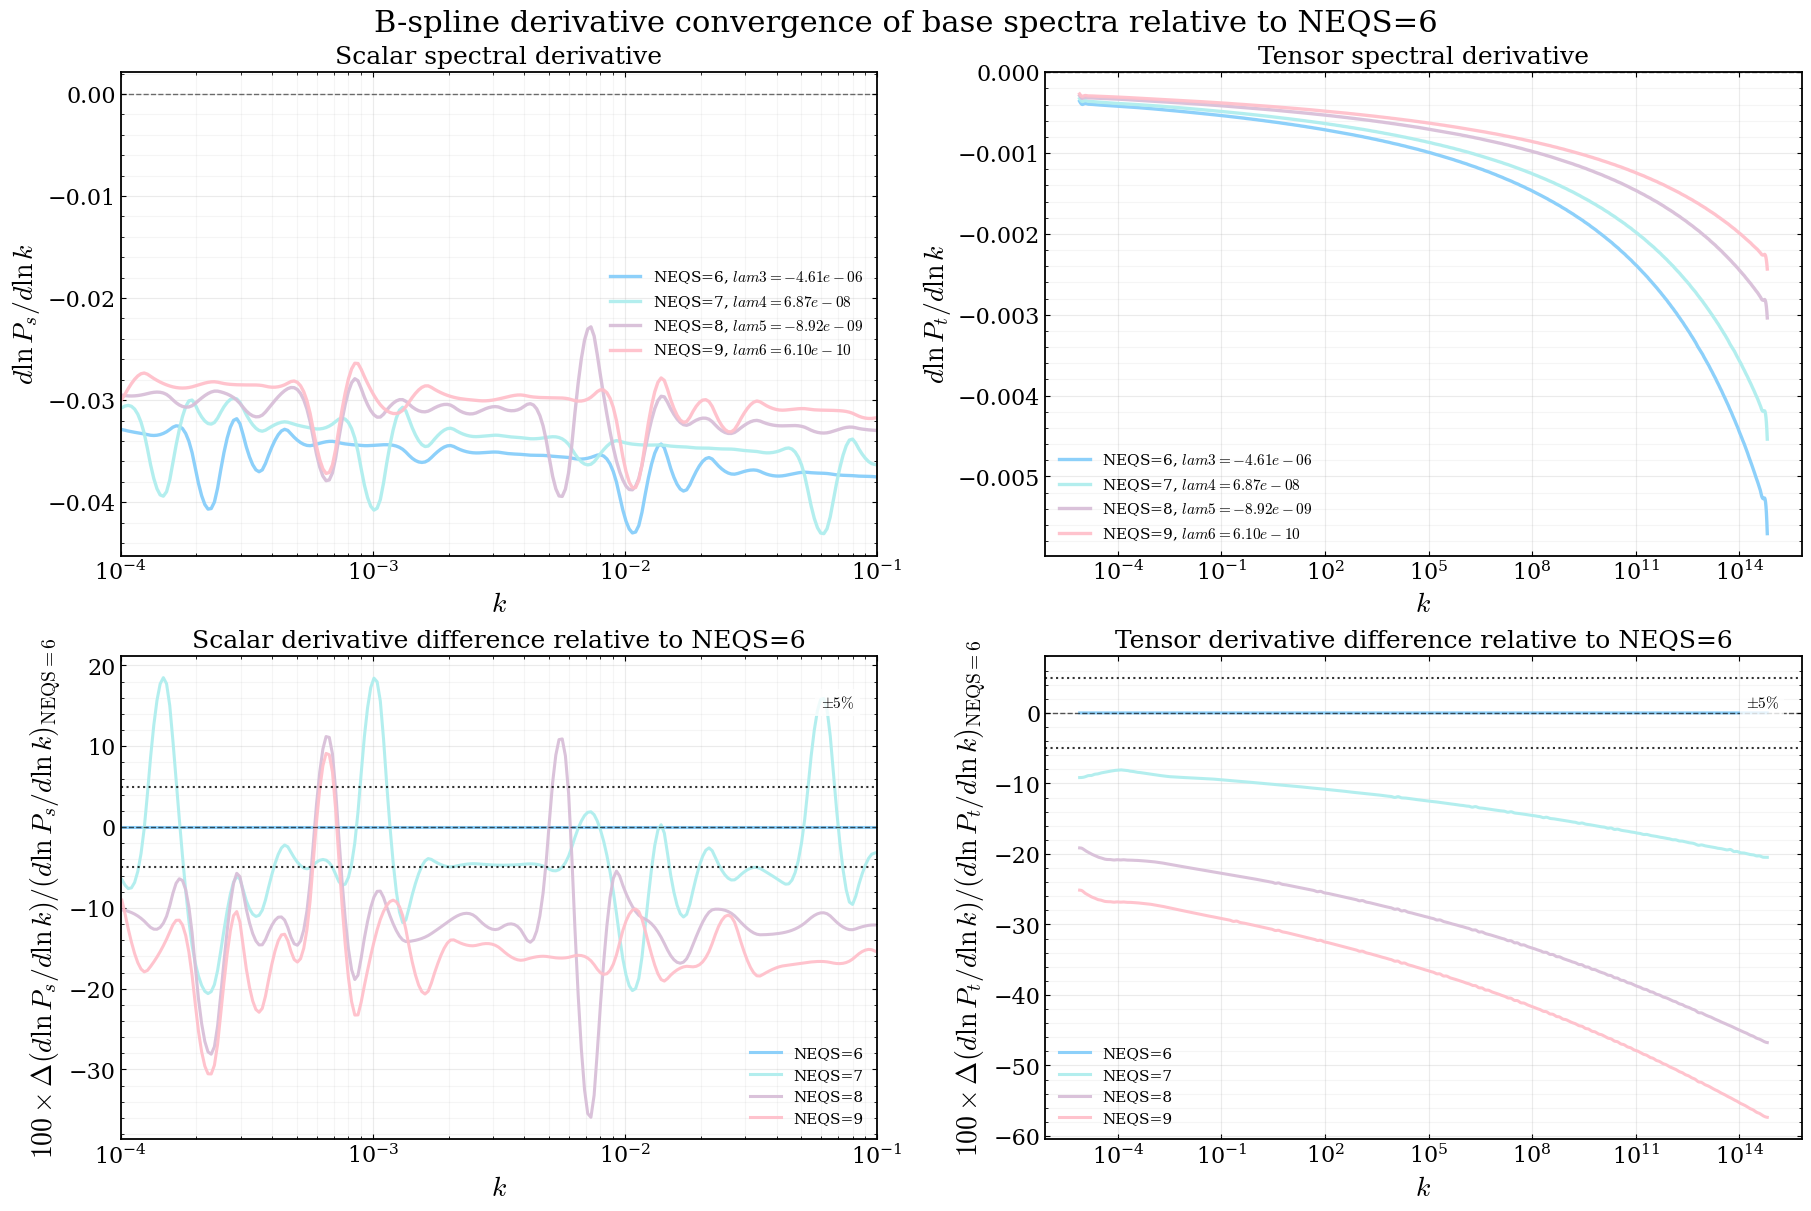


=== Base spectra derivative convergence summary ===
 NEQS param_name         value  mean_abs_dlnPs_pct  max_abs_dlnPs_pct  mean_abs_dlnPt_pct  max_abs_dlnPt_pct
    6       lam3 -4.609710e-06            0.000000           0.000000            0.000000           0.000000
    7       lam4  6.870650e-08            7.191512          20.610644           13.087898          20.483412
    8       lam5 -8.924610e-09           12.561458          35.919028           30.351934          46.754265
    9       lam6  6.100000e-10           15.735320          30.556379           38.119054          57.354214


In [113]:
deriv_summary_df = plot_base_spectra_derivative_convergence(
    base_path_root=base_path_root,
    base_params={
        6: ("lam3", -4.60971e-6),
        7: ("lam4",  6.87065e-8),
        8: ("lam5", -8.92461e-9),
        9: ("lam6", 6.1e-10),
    },
    ref_NEQS=6,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    tolerance=5.0,
    save_name="base_spectra_derivative_convergence_neqs6_8.png",
)

## AFTER APPLYING N-SHIFT

So far things have been fairly close, but when you account for the shift in $\Delta$$N$ you can see that they are actually even closer than you would suspect.

In [119]:
def test_k_shift_equivalence_scalar_tensor(
    base_path_root,
    base_params,
    base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def load_specs(NEQS, param, val):
        val_str = f"{val:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param}_{val_str}",
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmin=None, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    ref_param, ref_val = base_params[ref_NEQS]

    k_s_ref, Ps_ref_raw, k_t_ref, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_val,
    )

    Ps_ref = normalize_at_k(k_s_ref, Ps_ref_raw, k_norm)
    Pt_ref = normalize_at_k(k_t_ref, Pt_ref_raw, k_norm)

    ref_N_end = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS,
        "original_N_end",
    ].iloc[0]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_s, ax_t = axes[0]
    ax_s_err, ax_t_err = axes[1]

    scalar_ref_mask = np.ones_like(k_s_ref, dtype=bool)
    scalar_ref_mask &= k_s_ref >= k_min_scalar
    scalar_ref_mask &= k_s_ref <= k_max_scalar

    ax_s.loglog(
        k_s_ref[scalar_ref_mask],
        Ps_ref[scalar_ref_mask],
        lw=3.2,
        color="black",
        linestyle="--",
        label=rf"NEQS={ref_NEQS} reference",
    )

    ax_t.loglog(
        k_t_ref,
        Pt_ref,
        lw=3.2,
        color="black",
        linestyle="--",
        label=rf"NEQS={ref_NEQS} reference",
    )

    rows = []

    for NEQS, (param, val) in base_params.items():
        if NEQS == ref_NEQS:
            continue

        N_end = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS,
            "original_N_end",
        ].iloc[0]

        deltaN = N_end - ref_N_end

        print(f"NEQS={NEQS}")
        print(f"  N_end  = {N_end:.6f}")
        print(f"  deltaN = {deltaN:.6f}")
        print(f"  exp(-deltaN) = {np.exp(-deltaN):.6e}")

        k_s, Ps, k_t, Pt = load_specs(NEQS, param, val)

        k_s_shifted = k_s * np.exp(-deltaN)
        k_t_shifted = k_t * np.exp(-deltaN)

        Ps_shifted_norm = normalize_at_k(k_s_shifted, Ps, k_norm)
        Pt_shifted_norm = normalize_at_k(k_t_shifted, Pt, k_norm)

        color = colors.get(NEQS, None)
        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"

        scalar_mask = np.ones_like(k_s_shifted, dtype=bool)
        scalar_mask &= k_s_shifted >= k_min_scalar
        scalar_mask &= k_s_shifted <= k_max_scalar

        ax_s.loglog(
            k_s_shifted[scalar_mask],
            Ps_shifted_norm[scalar_mask],
            lw=2.5,
            linestyle="-",
            color=color,
            label=label,
        )

        ax_t.loglog(
            k_t_shifted,
            Pt_shifted_norm,
            lw=2.5,
            linestyle="-",
            color=color,
            label=label,
        )

        k_s_frac, frac_s = frac_on_ref_grid(
            k_s_ref,
            Ps_ref,
            k_s_shifted,
            Ps_shifted_norm,
            kmin=k_min_scalar,
            kmax=k_max_scalar,
        )

        k_t_frac, frac_t = frac_on_ref_grid(
            k_t_ref,
            Pt_ref,
            k_t_shifted,
            Pt_shifted_norm,
            kmin=None,
            kmax=None,
        )

        ax_s_err.semilogx(
            k_s_frac,
            100.0 * frac_s,
            lw=2.2,
            color=color,
            label=rf"NEQS={NEQS}",
        )

        ax_t_err.semilogx(
            k_t_frac,
            100.0 * frac_t,
            lw=2.2,
            color=color,
            label=rf"NEQS={NEQS}",
        )

        rows.append({
            "NEQS": NEQS,
            "param": param,
            "value": val,
            "original_N_end": N_end,
            "deltaN_from_ref": deltaN,
            "mean_abs_dPs_pct": 100.0 * np.nanmean(np.abs(frac_s)),
            "max_abs_dPs_pct": 100.0 * np.nanmax(np.abs(frac_s)),
            "mean_abs_dPt_pct": 100.0 * np.nanmean(np.abs(frac_t)),
            "max_abs_dPt_pct": 100.0 * np.nanmax(np.abs(frac_t)),
        })

    for ax in [ax_s, ax_t]:
        ax.axvline(
            k_norm,
            color="black",
            ls=":",
            lw=1.3,
            alpha=0.7,
        )

    for ax in [ax_s_err, ax_t_err]:
        ax.axhline(0.0, color="black", ls="--", lw=1.1, alpha=0.7)

        ax.axhline(
            tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.85,
        )

        ax.axhline(
            -tolerance,
            color="black",
            ls=":",
            lw=1.4,
            alpha=0.85,
        )

        ax.text(
            0.97,
            0.92,
            rf"$\pm {tolerance:.0f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
            ),
        )

    ax_s.set_title(r"Scalar spectra after $k \rightarrow k e^{-\Delta N}$")
    ax_t.set_title(r"Tensor spectra after $k \rightarrow k e^{-\Delta N}$")

    ax_s_err.set_title(rf"Scalar fractional difference relative to NEQS={ref_NEQS}")
    ax_t_err.set_title(rf"Tensor fractional difference relative to NEQS={ref_NEQS}")

    ax_s.set_xlabel(r"shifted $k$")
    ax_t.set_xlabel(r"shifted $k$")
    ax_s_err.set_xlabel(r"shifted $k$")
    ax_t_err.set_xlabel(r"shifted $k$")

    ax_s.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_t.set_ylabel(rf"$P_t/P_t(k={k_norm})$")

    ax_s_err.set_ylabel(rf"$100\times\Delta P_s/P_{{s,\rm NEQS={ref_NEQS}}}$")
    ax_t_err.set_ylabel(rf"$100\times\Delta P_t/P_{{t,\rm NEQS={ref_NEQS}}}$")

    ax_s.set_xlim(k_min_scalar, k_max_scalar)
    ax_s_err.set_xlim(k_min_scalar, k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(frameon=False, fontsize=11, loc="lower left")

    fig.suptitle(
        r"Testing whether base spectra differ mainly by a $k$-shift",
        fontsize=22,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Shifted base spectra summary ===")
    print(summary_df.to_string(index=False))

    return summary_df




NEQS=7
  N_end  = 941.837071
  deltaN = 2.673499
  exp(-deltaN) = 6.901037e-02
NEQS=8
  N_end  = 946.349733
  deltaN = 7.186161
  exp(-deltaN) = 7.569899e-04
NEQS=9
  N_end  = 948.989450
  deltaN = 9.825878
  exp(-deltaN) = 5.403505e-05


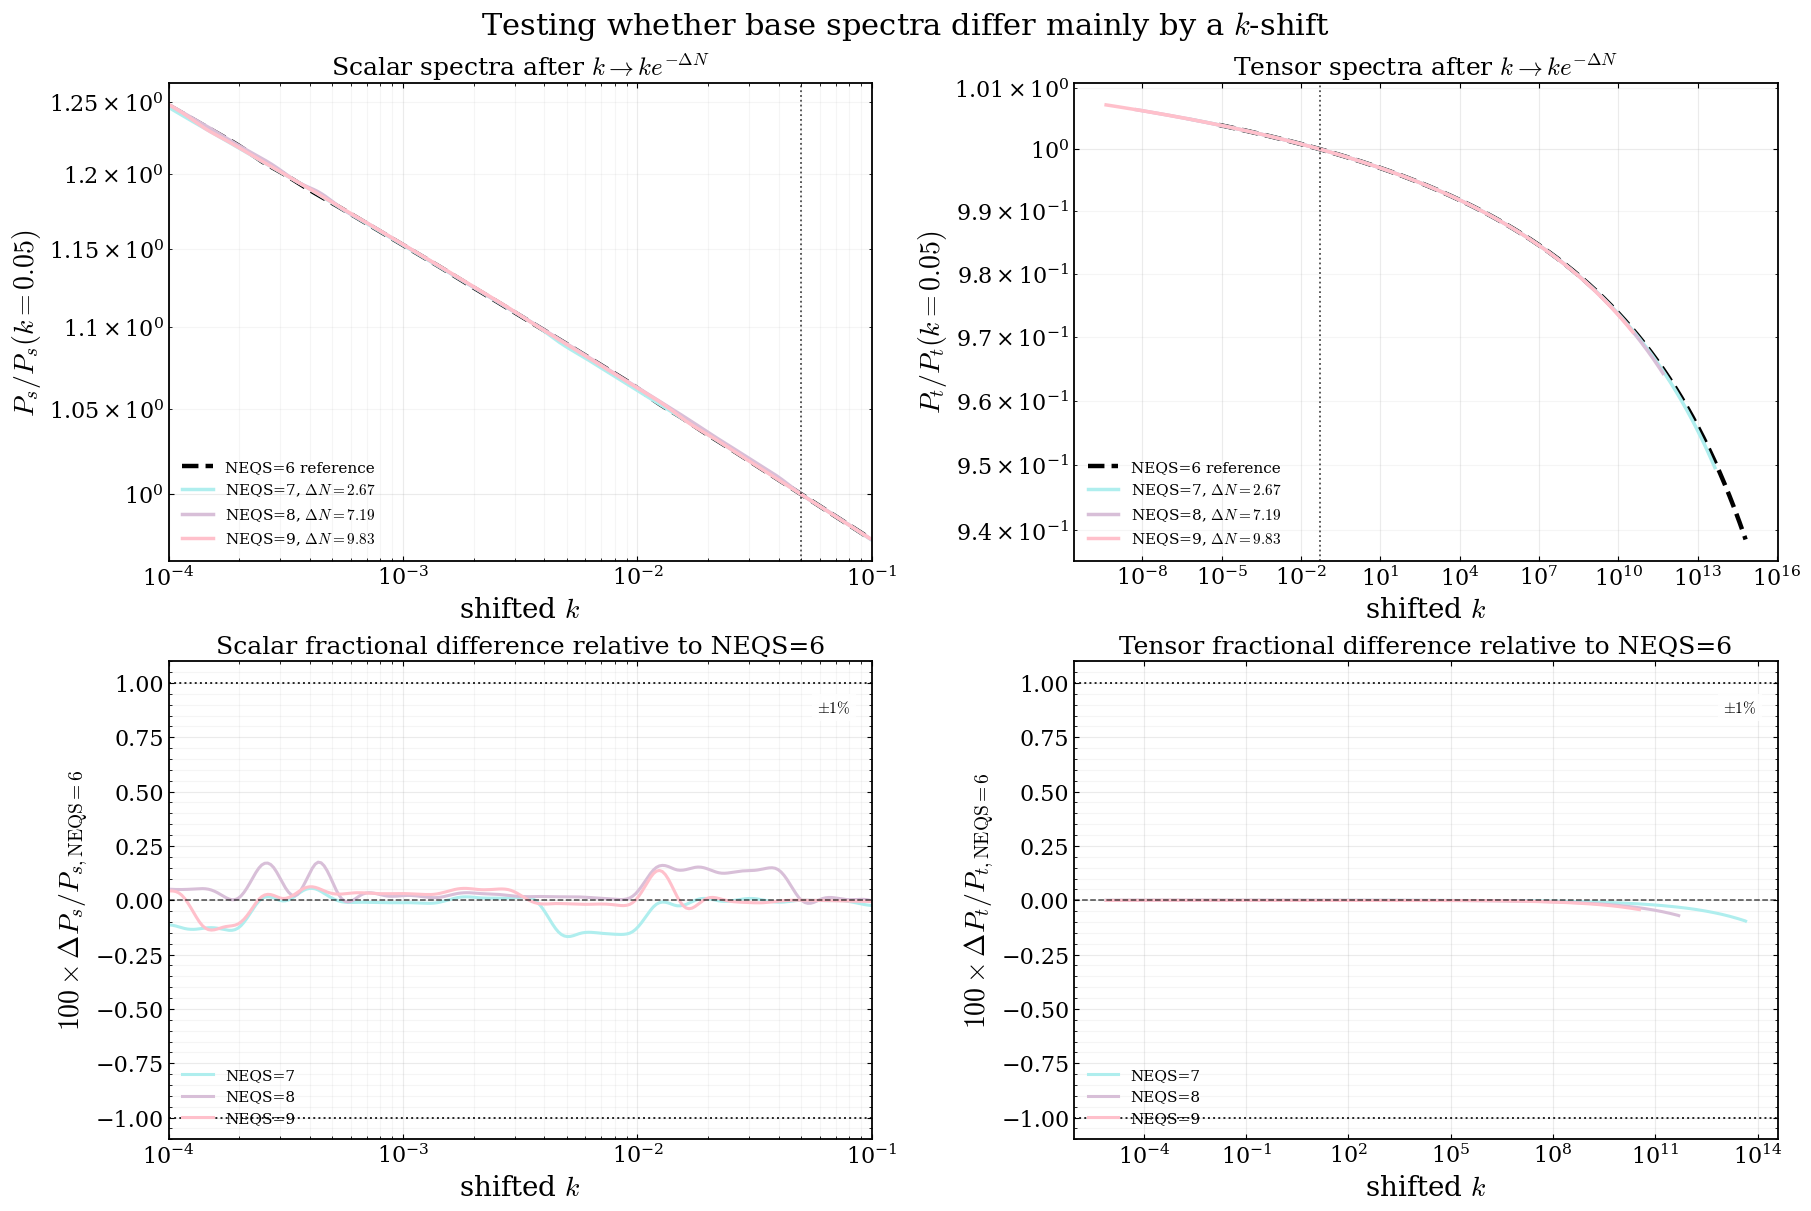


=== Shifted base spectra summary ===
 NEQS param         value  original_N_end  deltaN_from_ref  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
    7  lam4  6.870650e-08      941.837071         2.673499          0.043977         0.167149          0.009113         0.095929
    8  lam5 -8.924610e-09      946.349733         7.186161          0.056524         0.175395          0.006777         0.070482
    9  lam6  6.100000e-10      948.989450         9.825878          0.033591         0.137308          0.004238         0.043145


In [120]:
BASE_PARAMS = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
    9: ("lam6", 6.1e-10)
}

kshift_summary_df = test_k_shift_equivalence_scalar_tensor(
    base_path_root=base_path_root,
    base_params=BASE_PARAMS,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    tolerance=1.0,
    save_name="base_scalar_tensor_kshift_equivalence_relative_to_neqs6.png",
)



And we can again examine the derivatives of the power spectra:

In [121]:
def plot_base_spectra_derivatives_bspline_2x2_kshifted(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    apply_k_shift=True,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name=None,
    show=True,
):
    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
            9: ("lam6", 6.1e-10),
        }
        
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    def get_N_end(summary_df, NEQS):
        matches = summary_df.loc[summary_df["NEQS"].astype(int) == int(NEQS)]

        if len(matches) == 0:
            raise ValueError(f"No original_N_end found for NEQS={NEQS}")

        return float(matches.iloc[0]["original_N_end"])

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (
            (k > 0)
            & (P > 0)
            & np.isfinite(k)
            & np.isfinite(P)
        )

        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        x_unique = np.unique(x)
        y_unique = np.array([
            np.mean(y[x == xu]) for xu in x_unique
        ])

        if len(x_unique) < 4:
            raise ValueError("Need at least 4 unique k values for cubic spline.")

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        d1 = spl.derivative(1)(x_unique)
        d2 = spl.derivative(2)(x_unique)

        return np.exp(x_unique), d1, d2

    def apply_k_window(k, y, kmin=None, kmax=None):
        mask = np.ones_like(k, dtype=bool)

        if kmin is not None:
            mask &= k >= kmin

        if kmax is not None:
            mask &= k <= kmax

        return k[mask], y[mask]

    ref_N_end = get_N_end(base_summary_df, ref_NEQS)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_d1Ps, ax_d1Pt = axes[0]
    ax_d2Ps, ax_d2Pt = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)

        if apply_k_shift:
            N_end = get_N_end(base_summary_df, NEQS)
            deltaN = N_end - ref_N_end

            k_s = k_s * np.exp(-deltaN)
            k_t = k_t * np.exp(-deltaN)
        else:
            N_end = get_N_end(base_summary_df, NEQS)
            deltaN = 0.0

        k_s_use, d1Ps, d2Ps = prepare_log_spline(
            k_s,
            Ps,
            smoothing=smoothing,
        )

        k_t_use, d1Pt, d2Pt = prepare_log_spline(
            k_t,
            Pt,
            smoothing=smoothing,
        )

        k_s_d1, d1Ps_plot = apply_k_window(
            k_s_use,
            d1Ps,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_s_d2, d2Ps_plot = apply_k_window(
            k_s_use,
            d2Ps,
            kmin=k_min_plot_s,
            kmax=k_max_plot_s,
        )

        k_t_d1, d1Pt_plot = apply_k_window(
            k_t_use,
            d1Pt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        k_t_d2, d2Pt_plot = apply_k_window(
            k_t_use,
            d2Pt,
            kmin=k_min_plot_t,
            kmax=k_max_plot_t,
        )

        color = colors.get(NEQS, None)

        if apply_k_shift:
            label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"
        else:
            label = rf"NEQS={NEQS}"

        ax_d1Ps.semilogx(
            k_s_d1,
            d1Ps_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d1Pt.semilogx(
            k_t_d1,
            d1Pt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d2Ps.semilogx(
            k_s_d2,
            d2Ps_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        ax_d2Pt.semilogx(
            k_t_d2,
            d2Pt_plot,
            color=color,
            lw=2.4,
            alpha=0.95,
            label=label,
        )

        rows.append({
            "NEQS": NEQS,
            "param_name": param_name,
            "value": value,
            "original_N_end": N_end,
            "deltaN_from_ref": deltaN,
            "exp_minus_deltaN": np.exp(-deltaN),
            "k_s_min_shifted": np.nanmin(k_s_use),
            "k_s_max_shifted": np.nanmax(k_s_use),
            "k_t_min_shifted": np.nanmin(k_t_use),
            "k_t_max_shifted": np.nanmax(k_t_use),
        })

    shift_label = (
        r"$k \rightarrow k e^{-\Delta N}$"
        if apply_k_shift
        else r"no $k$ shift"
    )

    # Titles
    ax_d1Ps.set_title(rf"Scalar first derivative after {shift_label}")
    ax_d1Pt.set_title(rf"Tensor first derivative after {shift_label}")
    ax_d2Ps.set_title(rf"Scalar second derivative after {shift_label}")
    ax_d2Pt.set_title(rf"Tensor second derivative after {shift_label}")

    # Labels
    ax_d1Ps.set_ylabel(r"$d\ln P_s/d\ln k$")
    ax_d1Pt.set_ylabel(r"$d\ln P_t/d\ln k$")
    ax_d2Ps.set_ylabel(r"$d^2\ln P_s/d(\ln k)^2$")
    ax_d2Pt.set_ylabel(r"$d^2\ln P_t/d(\ln k)^2$")

    for ax in axes.ravel():
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.55,
        )

        ax.set_xlabel(r"shifted $k$" if apply_k_shift else r"$k$")

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(
                frameon=False,
                fontsize=11,
                loc="best",
            )

    if k_min_plot_s is not None or k_max_plot_s is not None:
        xmin_s = k_min_plot_s if k_min_plot_s is not None else None
        xmax_s = k_max_plot_s if k_max_plot_s is not None else None
        ax_d1Ps.set_xlim(xmin_s, xmax_s)
        ax_d2Ps.set_xlim(xmin_s, xmax_s)

    if k_min_plot_t is not None or k_max_plot_t is not None:
        xmin_t = k_min_plot_t if k_min_plot_t is not None else None
        xmax_t = k_max_plot_t if k_max_plot_t is not None else None
        ax_d1Pt.set_xlim(xmin_t, xmax_t)
        ax_d2Pt.set_xlim(xmin_t, xmax_t)

    fig.suptitle(
        rf"B-spline spectral derivatives for base models after {shift_label}",
        fontsize=22,
    )

    if save_name is None:
        suffix = "kshifted" if apply_k_shift else "unshifted"
        save_name = f"base_spectra_derivatives_neqs6_8_{suffix}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(rows)

    print("\n=== Shifted derivative summary ===")
    print(summary_df.to_string(index=False))

    return summary_df



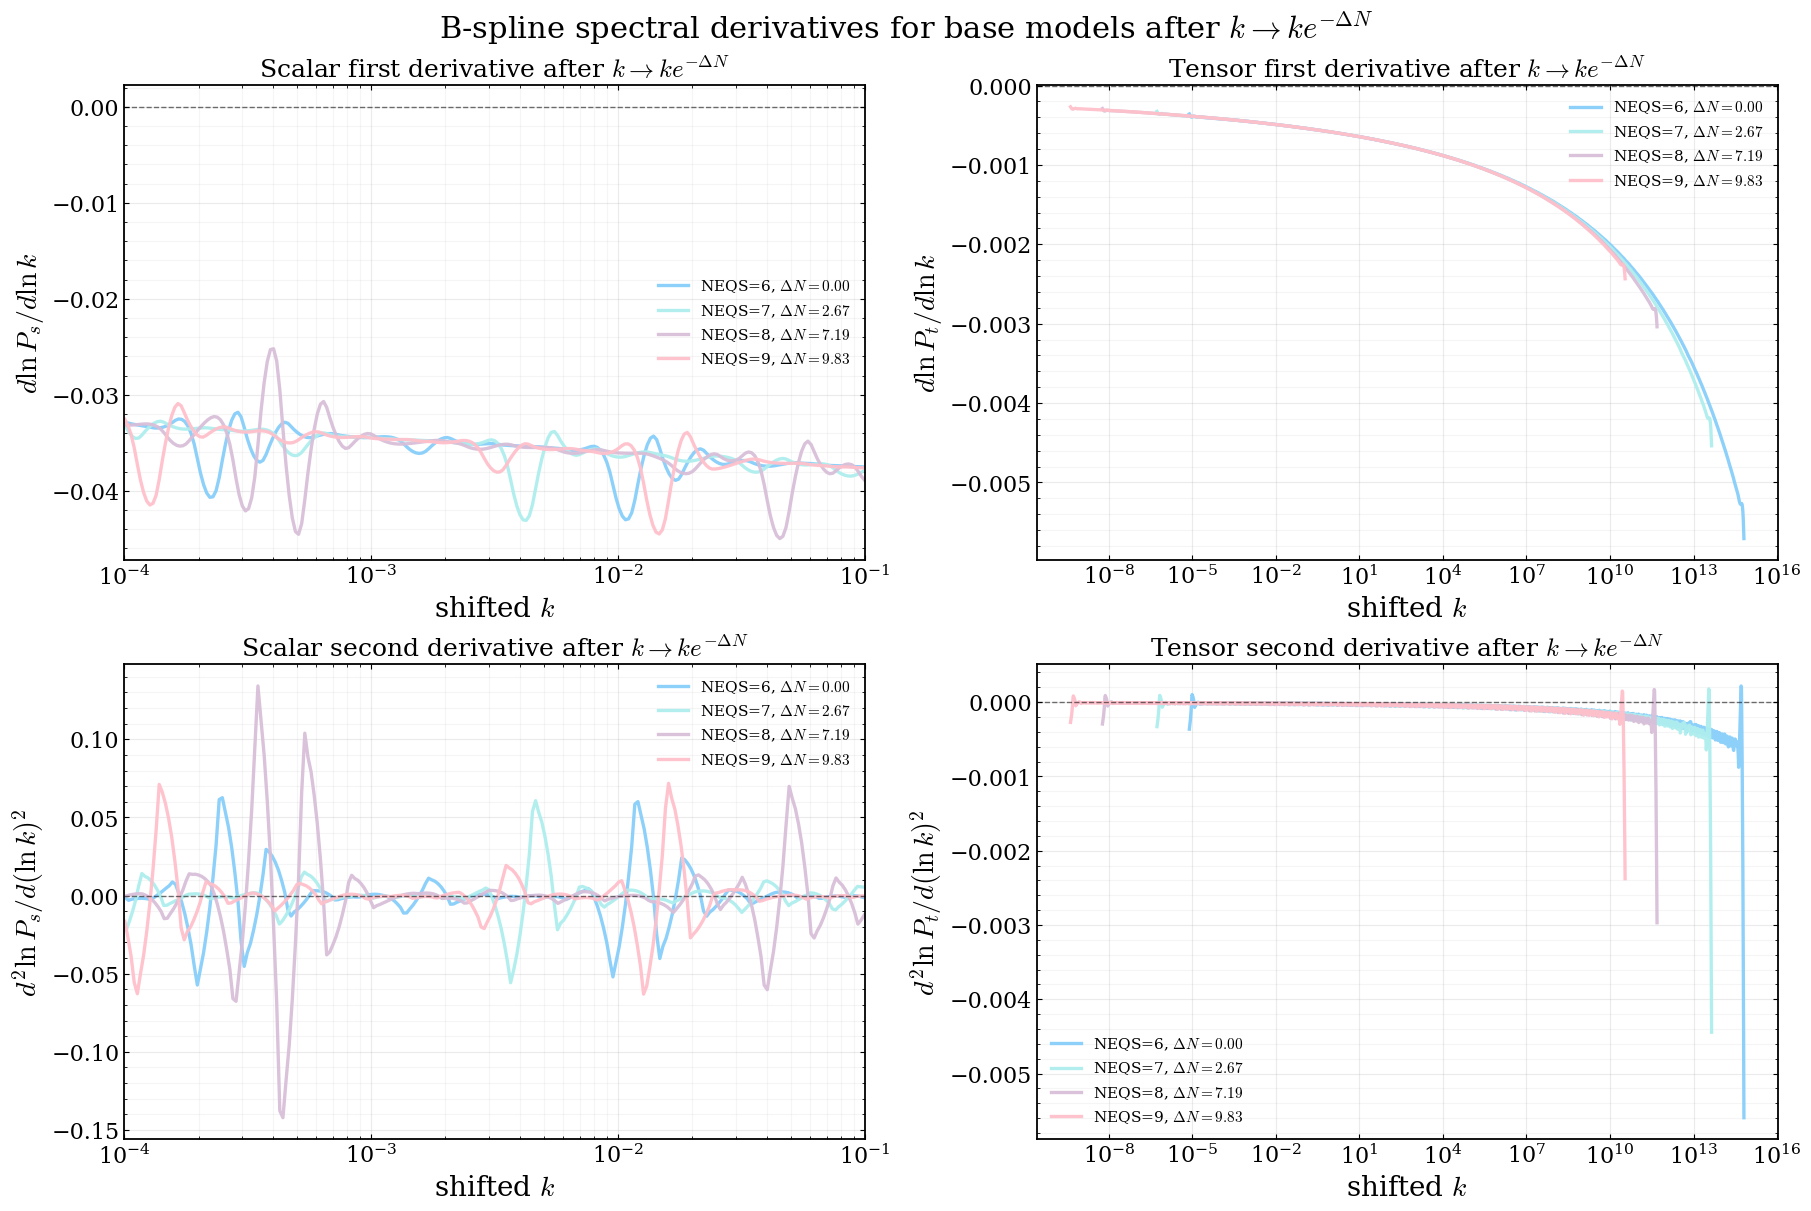


=== Shifted derivative summary ===
 NEQS param_name         value  original_N_end  deltaN_from_ref  exp_minus_deltaN  k_s_min_shifted  k_s_max_shifted  k_t_min_shifted  k_t_max_shifted
    6       lam3 -4.609710e-06      939.163572         0.000000          1.000000     7.791357e-06     6.470000e+14     7.791357e-06     6.470000e+14
    7       lam4  6.870650e-08      941.837071         2.673499          0.069010     5.376844e-07     4.464971e+13     5.376844e-07     4.464971e+13
    8       lam5 -8.924610e-09      946.349733         7.186161          0.000757     5.897978e-09     4.897725e+11     5.897978e-09     4.897725e+11
    9       lam6  6.100000e-10      948.989450         9.825878          0.000054     4.210064e-10     3.496068e+10     4.210064e-10     3.496068e+10


In [122]:
deriv_shift_summary_df = plot_base_spectra_derivatives_bspline_2x2_kshifted(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    apply_k_shift=True,
    k_min_plot_s=1e-4,
    k_max_plot_s=1e-1,
    k_min_plot_t=None,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name="base_spectra_derivatives_neqs6_8_kshifted.png",
    
)

